# H1 vs. H2: the two toy encodings, drawn

Schematic for the two hypotheses in
[`claude_notes/stim_belief_alignment_updated.md`](../claude_notes/stim_belief_alignment_updated.md).
Two toy neurons `r_1`, `r_2`; each group is one point in their joint firing-rate space, and the
two axes under study are the arrows between consecutive groups:

```
v_stim = (selected, not preferred)  -  (not selected, not preferred)
v_pref = (selected, preferred)      -  (selected, not preferred)
```

**H1 -- disjoint.** `r_1` encodes selection, `r_2` encodes preference; the two arrows are
orthogonal. The choice decoder generalizes poorly to preference, `cos(v_stim, v_pref) = 0`.

| | not selected, not preferred | selected, not preferred | selected, preferred | $v_{stim}$ | $v_{pref}$ |
|---|---|---|---|---|---|
| $r_1$ | 0 | 1 | 1 | 1 | 0 |
| $r_2$ | 0 | 0 | 1 | 0 | 1 |

**H2 -- aligned.** Both neurons encode selection, and preferring the feature just scales that
same pattern up; the two arrows are collinear. The decoder generalizes,
`cos(v_stim, v_pref) = 1`.

| | not selected, not preferred | selected, not preferred | selected, preferred | $v_{stim}$ | $v_{pref}$ |
|---|---|---|---|---|---|
| $r_1$ | 0 | 1 | 2 | 1 | 1 |
| $r_2$ | 0 | 1 | 2 | 1 | 1 |

These are the *noiseless* predictions. What a measured cosine actually lands on in this design
is a separate question -- see
[`20260812_cosine_noise_bias_toys.ipynb`](20260812_cosine_noise_bias_toys.ipynb),
which shows the raw cosine sits near -0.65 under H1 rather than 0, and shrunk toward 0 under H2.

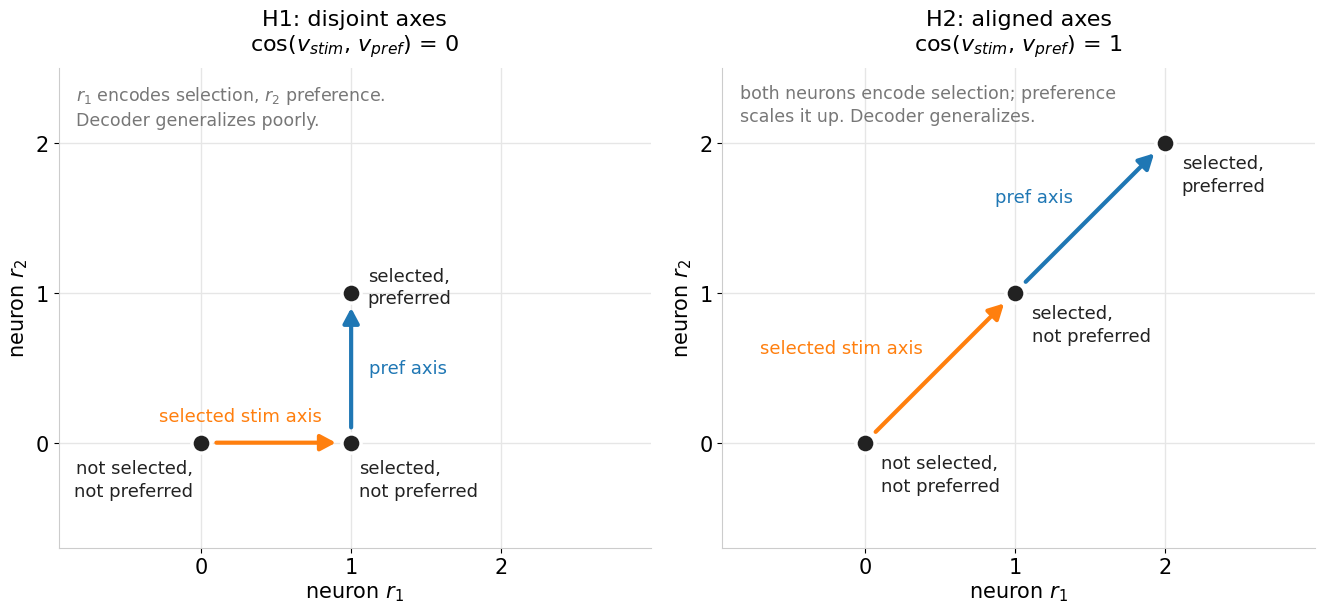

In [2]:
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams.update({"font.size": 15})

# the repo's existing decoder-mode colors, from utils.visualization_utils.MODE_TO_COLOR:
# mode "choice" -> display name "feature" -> tab:orange;  mode "pref" -> "preference" -> tab:blue.
# Hard-coded rather than imported so this schematic has no repo dependency.
STIM_COLOR = "tab:orange"
PREF_COLOR = "tab:blue"
INK, MUTED, GRID = "#222222", "#777777", "#e6e6e6"

GROUP_LABELS = {
    "A": "not selected,\nnot preferred",
    "B": "selected,\nnot preferred",
    "C": "selected,\npreferred",
}

# offsets are (dx pts, dy pts, ha, va) -- hand-placed so nothing collides with an arrow
HYPOTHESES = {
    "H1": dict(
        title="H1: disjoint axes",
        blurb="$r_1$ encodes selection, $r_2$ preference.\nDecoder generalizes poorly.",
        coords={"A": (0.0, 0.0), "B": (1.0, 0.0), "C": (1.0, 1.0)},
        group_offsets={"A": (-6, -12, "right", "top"), "B": (6, -12, "left", "top"), "C": (12, 4, "left", "center")},
        axis_offsets={"stim": (-26, 13, "center", "bottom"), "pref": (13, 0, "left", "center")},
    ),
    "H2": dict(
        title="H2: aligned axes",
        blurb="both neurons encode selection; preference\nscales it up. Decoder generalizes.",
        coords={"A": (0.0, 0.0), "B": (1.0, 1.0), "C": (2.0, 2.0)},
        group_offsets={g: (12, -8, "left", "top") for g in "ABC"},
        axis_offsets={"stim": (-12, 8, "right", "bottom"), "pref": (-12, 8, "right", "bottom")},
    ),
}

# shared across both panels so the two encodings sit in one metric
XLIM, YLIM = (-0.95, 3.0), (-0.7, 2.5)


def cos_sim(v1, v2):
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))


def style(ax):
    """Recessive grid, no top/right spines."""
    ax.set_axisbelow(True)
    ax.grid(True, color=GRID, linewidth=1)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#cccccc")


def draw(ax, spec):
    style(ax)
    pts = {g: np.array(xy) for g, xy in spec["coords"].items()}
    v_stim, v_pref = pts["B"] - pts["A"], pts["C"] - pts["B"]

    for name, start, end, color, label in (
        ("stim", pts["A"], pts["B"], STIM_COLOR, "selected stim axis"),
        ("pref", pts["B"], pts["C"], PREF_COLOR, "pref axis"),
    ):
        ax.annotate("", xy=end, xytext=start, zorder=3, arrowprops=dict(
            arrowstyle="-|>,head_width=0.32,head_length=0.6", linewidth=3,
            color=color, shrinkA=11, shrinkB=11))
        dx, dy, ha, va = spec["axis_offsets"][name]
        ax.annotate(label, (start + end) / 2, textcoords="offset points", xytext=(dx, dy),
                    ha=ha, va=va, fontsize=13, color=color, zorder=6)

    # the three groups, direct-labeled by what they are rather than by a letter
    for g, pt in pts.items():
        ax.scatter(*pt, s=190, color=INK, edgecolors="white", linewidths=2.5, zorder=5)
        dx, dy, ha, va = spec["group_offsets"][g]
        ax.annotate(GROUP_LABELS[g], pt, textcoords="offset points", xytext=(dx, dy),
                    ha=ha, va=va, fontsize=13, color=INK, zorder=6, linespacing=1.35)

    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.set_aspect("equal")
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xlabel("neuron $r_1$")
    ax.set_ylabel("neuron $r_2$")
    ax.set_title(f"{spec['title']}\ncos($v_{{stim}}$, $v_{{pref}}$) = {cos_sim(v_stim, v_pref):.0f}",
                 fontsize=16, pad=12)
    ax.annotate(spec["blurb"], xy=(0.03, 0.965), xycoords="axes fraction", va="top",
                fontsize=12.5, color=MUTED, linespacing=1.35)


fig, axs = plt.subplots(1, 2, figsize=(13.5, 6.4))
for ax, key in zip(axs, HYPOTHESES):
    draw(ax, HYPOTHESES[key])
# no legend box: every arrow is direct-labeled, so identity is never carried by color alone, and a
# legend would only repeat those labels.
plt.tight_layout()
plt.show()

In [3]:
# save alongside the other schematic figures
# fig.savefig("/data/patrick_res/figures/wcst_paper/stim_belief_hypotheses.svg", bbox_inches="tight")